# Conteo de datos

ETAPA: 51169

Cerrada/Perdida: 1282
- Convocado: 1
- NA: 1280
- Pruebas calificadas: 1

Comision de estudios de postgrado: 0
- Aplazada
- Completa 
- Convocado
- Desmatriculado
- Enviada
- Incompleta
- Inicio
- Matriculado
- Matriculado parcialmente
- NA
- No formalizada
- No presentado
- Opción ofertada
- Pago mínimo
- Prematriculado
- Propuesta reorientados
- Pruebas calificadas
- Publicada
- Recibida
- Recibido admisión
- Respuesta candidato
- Resuelta
- Validada

Enviada: 49
- NA: 49

Estudio Centro: 8200
- Aplazada: 6
- NA: 3
- Pruebas calificadas: 1
- Recibida: 4348
- Resuelta: 3842

Informacion: 12
- NA: 12

Información: 3547
- NA: 574
- Recibida: 2943
- Validada: 30

Inicio: 9599
- NA: 9599


Matrícula OOGG: 4
- No formalizada: 4


Matrícula Admisión: 1356
Desmatriculado: 1
- Enviada: 3
- Inicio: 574
- Matriculado: 1
- Matriculado parcialmente: 448
- Pago mínimo: 299
- Prematriculado: 30

Propuesta centro: 5398
- NA: 1
- Opción ofertada: 32
- Recibida: 1576
- Validada: 3789

Pruebas de admision: 6024
- Convocado: 2556
- No presentado: 145
- Pruebas calificadas: 3323

Reorientación: 178
- Propuesta reorientados: 32
- Recibido admisión: 144
- Respuesta candidato: 2

Resolución: 643
- Publicada: 643

Stand By: 247
- Recibida: 231
- Validada: 16

Validación: 13640
- Completa: 5752
- Convocado: 1
- Incompleta: 1815
- Pruebas calificadas: 2
- Recibida: 6070

In [ ]:
import pandas as pd
import oracledb

In [ ]:
pip show oracledb

In [17]:
import os
from dotenv import load_dotenv
import pandas as pd
import oracledb

# Cargar variables desde .env
load_dotenv()  # lee .env en el directorio actual

DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_DSN  = os.getenv("DB_DSN")   # ej: //host:1521/servicio

# Verificación rápida (no imprime la contraseña)
print("Usuario:", DB_USER)
print("DSN:", DB_DSN)
print("Contraseña cargada:", "Sí" if DB_PASS else "NO — revisa el .env")


Usuario: PMAT_BTCH[PMATOWNER]
DSN: //racdb-pre.si.unav.es:1521/UNSIDPRE.UNAV
Contraseña cargada: Sí


In [18]:
import oracledb
conn = oracledb.connect(user=DB_USER, password=DB_PASS, dsn=DB_DSN)
print("Conexión OK")

Conexión OK


In [19]:
# Conectar a Oracle SIN tnsnames.ora (evita DPY-4027) y verificar variables

import os, oracledb
from dotenv import load_dotenv

load_dotenv(override=True)

# Requeridas en .env
req = ["DB_USER","DB_PASS","ORA_HOST","ORA_PORT","ORA_SERVICE"]
vals = {k: os.getenv(k) for k in req}
print("Vars:", vals)

missing = [k for k,v in vals.items() if not v]
if missing:
    raise SystemExit(f"Faltan en .env: {missing}\nEjemplo:\nDB_HOST=mi-host\nDB_PORT=1521\nDB_SERVICE=mi_servicio")

# Forzar a no usar TNS
os.environ.pop("TNS_ADMIN", None)

# DSN programático
dsn = oracledb.makedsn(host=vals["ORA_HOST"], port=int(vals["ORA_PORT"]), service_name=vals["ORA_SERVICE"])

# Conexión
conn = oracledb.connect(user=vals["DB_USER"], password=vals["DB_PASS"], dsn=dsn)

# Prueba
with conn.cursor() as cur:
    cur.execute("select 1 from dual")
    print("OK Oracle:", cur.fetchone())
conn.close()


Vars: {'DB_USER': 'PMAT_BTCH[PMATOWNER]', 'DB_PASS': 'w6IT%_)M>&', 'ORA_HOST': 'racdb-pre.si.unav.es', 'ORA_PORT': '1521', 'ORA_SERVICE': 'UNSIDPRE.UNAV'}
OK Oracle: (1,)


In [20]:
import sys, os
from dotenv import load_dotenv
load_dotenv()

# Primero se añade la ruta, LUEGO se importa
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(project_root, 'src'))
print("Ruta src:", os.path.join(project_root, 'src'))

import oracledb
from oracle_connector import OracleConnector   # ← ahora sí funciona
import pandas as pd

conn = OracleConnector()
df = pd.DataFrame(conn.read_table('PMAT_PREDICTION'))
df['TARGET_REAL'] = pd.to_numeric(df['TARGET_REAL'], errors='coerce')

print(f"Total registros         : {len(df):,}")
print(f"Con TARGET_REAL         : {df['TARGET_REAL'].notna().sum():,}")
print(f"Sin TARGET_REAL (null)  : {df['TARGET_REAL'].isna().sum():,}")
print(f"TARGET_REAL = 1 (matr.) : {(df['TARGET_REAL']==1).sum():,}")
print(f"TARGET_REAL = 0 (no m.) : {(df['TARGET_REAL']==0).sum():,}")

Ruta src: c:\Users\malmendrosv\UNAV\src
Total registros         : 51,219
Con TARGET_REAL         : 51,219
Sin TARGET_REAL (null)  : 0
TARGET_REAL = 1 (matr.) : 9
TARGET_REAL = 0 (no m.) : 51,210


# Bloque 1: Verficando la presencia de datos en TARGET_REAL

In [13]:
# --- Verificación de TARGET_REAL en una sola celda ---

import os, sys
sys.path.insert(0, 'UNAV/src')

from dotenv import load_dotenv; load_dotenv()
import pandas as pd

try:
    from oracle_connector import OracleConnector
except ModuleNotFoundError as e:
    raise SystemExit(
        "No se pudo importar oracle_connector. Asegúrate de tener 'src' en la ruta y el archivo src/oracle_connector.py."
    ) from e

# 1) Conectar y leer la tabla
TABLE_NAME = 'PMAT_PREDICTION'
conn = OracleConnector()
df = pd.DataFrame(conn.read_table(TABLE_NAME))

# 2) Normalizar TARGET_REAL a numérico (no convertibles -> NaN)
if 'TARGET_REAL' not in df.columns:
    raise SystemExit(f"La columna TARGET_REAL no existe en {TABLE_NAME}.")

df['TARGET_REAL'] = pd.to_numeric(df['TARGET_REAL'], errors='coerce')

# 3) Cálculos
total = len(df)
no_nulos = df['TARGET_REAL'].notna().sum()
nulos = df['TARGET_REAL'].isna().sum()
eq1 = (df['TARGET_REAL'] == 1).sum()
eq0 = (df['TARGET_REAL'] == 0).sum()
tiene_datos = no_nulos > 0

# 4) Salida formateada
print(f"Tabla                 : {TABLE_NAME}")
print(f"Total registros       : {total:,}")
print(f"TARGET_REAL no nulos  : {no_nulos:,}")
print(f"TARGET_REAL nulos     : {nulos:,}")
print(f"TARGET_REAL = 1       : {eq1:,}")
print(f"TARGET_REAL = 0       : {eq0:,}")
print(f"¿TARGET_REAL tiene datos? -> {tiene_datos}")

# 5) (Opcional) Muestra rápida de valores distintos y primeras filas con dato
print("\nValores distintos de TARGET_REAL (top 10):")
print(df['TARGET_REAL'].dropna().value_counts().head(10))

print("\nPrimeras filas con TARGET_REAL no nulo:")
display(df[df['TARGET_REAL'].notna()].head(5))


Tabla                 : PMAT_PREDICTION
Total registros       : 51,212
TARGET_REAL no nulos  : 51,212
TARGET_REAL nulos     : 0
TARGET_REAL = 1       : 5
TARGET_REAL = 0       : 51,207
¿TARGET_REAL tiene datos? -> True

Valores distintos de TARGET_REAL (top 10):
TARGET_REAL
0    51207
1        5
Name: count, dtype: int64

Primeras filas con TARGET_REAL no nulo:


,OPP_ID_ETAPA_COMP,OPP_ID,ETAPA,SUBETAPA,TARGET_REAL,TARGET_PRED,PROBABILIDAD,CONFIANZA,MODELO,EXPLICACION,FECHA_PRED,FECHA_ACTUALIZACION,FECHA_INICIO_ETAPA
0,0066900001dHQILAA4__Inicio__NA,0066900001dHQILAA4,Inicio,NA,0,0,1.54,96.92,grado_v1,"{""top_features"": [{""feature"": ""etapa_ordinal_n...",2026-03-26T16:35:25.939889,2026-03-26T16:35:25.939889,2026-01-16 07:13:56
1,0066900001g51JkAAI__Información__NA,0066900001g51JkAAI,Información,NA,0,0,29.59,40.82,grado_v1,"{""top_features"": [{""feature"": ""tiempo_entre_et...",2026-03-26T13:33:00.201255,2026-03-26T13:33:00.201255,2023-04-27 13:43:07
2,0066900001g51JkAAI__Inicio__NA,0066900001g51JkAAI,Inicio,NA,0,0,11.61,76.78,grado_v1,"{""top_features"": [{""feature"": ""PL_SITUACION_SO...",2026-03-26T16:35:25.939889,2026-03-26T16:35:25.939889,2025-05-12 17:57:00
3,0066900001hU2nnAAC__Información__NA,0066900001hU2nnAAC,Información,NA,0,0,9.95,80.10,grado_v1,"{""top_features"": [{""feature"": ""tiempo_entre_et...",2026-03-26T13:33:00.201255,2026-03-26T13:33:00.201255,2023-09-04 15:27:39
4,0066900001hU2nnAAC__Inicio__NA,0066900001hU2nnAAC,Inicio,NA,0,0,12.00,76.00,grado_v1,"{""top_features"": [{""feature"": ""etapa_ordinal_n...",2026-03-26T16:35:25.939889,2026-03-26T16:35:25.939889,2025-06-12 01:19:28


#### Con respecto a la pregunta "¿TARGET_REAL tiene datos?", la respuesta es que sí, pero como se ve en los valores extraídos, es ciertamente negativo puesto que solo hay datos en la franja de los no matriculados.

## Tarea 1.1 — Contar cuántos registros tienen TARGET_REAL

In [14]:
import pandas as pd, sys
sys.path.insert(0, 'src')
from dotenv import load_dotenv; load_dotenv()
from oracle_connector import OracleConnector

conn = OracleConnector()
df = pd.DataFrame(conn.read_table('PMAT_PREDICTION'))
df['TARGET_REAL'] = pd.to_numeric(df['TARGET_REAL'], errors='coerce')

total = len(df)
con_tr = df['TARGET_REAL'].notna().sum()
sin_tr = df['TARGET_REAL'].isna().sum()
eq1 = (df['TARGET_REAL'] == 1).sum()
eq0 = (df['TARGET_REAL'] == 0).sum()

p = lambda x: f"{(x/total*100 if total else 0):.2f}%"

print(f"Total registros               : {total:,}")
print(f"Con TARGET_REAL               : {con_tr:,} ({p(con_tr)})")
print(f"Sin TARGET_REAL (null)        : {sin_tr:,} ({p(sin_tr)})")
print(f"TARGET_REAL = 1 (matr.)       : {eq1:,} ({p(eq1)})")
print(f"TARGET_REAL = 0 (no m.)       : {eq0:,} ({p(eq0)})")


Total registros               : 51,212
Con TARGET_REAL               : 51,212 (100.00%)
Sin TARGET_REAL (null)        : 0 (0.00%)
TARGET_REAL = 1 (matr.)       : 5 (0.01%)
TARGET_REAL = 0 (no m.)       : 51,207 (99.99%)


#### Debido a que el porcentaje obtenido es del 100%, se asume que el curso aún no esta cerrado aún, por lo que las métricas no son del todo válidas. Aun con eso, se entiende que el modelo puede estar funcionando correctamente.

# BLOQUE 2 — Analizar en qué etapas están los candidatos

#### Solo ETAPA

In [ ]:
import pandas as pd, sys
sys.path.insert(0, 'src')
from dotenv import load_dotenv; load_dotenv()
from oracle_connector import OracleConnector

TABLE = 'PMAT_PREDICTION'
conn = OracleConnector()
df = pd.DataFrame(conn.read_table(TABLE))

# Normaliza y limpia ETAPA
df.columns = [c.strip().upper() for c in df.columns]
if 'ETAPA' not in df.columns:
    raise SystemExit("No existe la columna ETAPA.")
df['ETAPA'] = df['ETAPA'].astype(str).str.strip()

total = len(df)
counts = df['ETAPA'].value_counts(dropna=False)
pct = (counts / total * 100).round(2)

print(f"Tabla: {TABLE}")
print(f"Total registros: {total:,}\n")

print("Conteo por ETAPA:")
display(counts.to_frame('total'))

print("\nPorcentaje por ETAPA (%):")
display(pct.to_frame('pct'))

# (Opcional) Top N
N = 10
print(f"\nTop {N} ETAPA por volumen:")
display(counts.head(N).to_frame('total'))

# (Opcional) Gráfico rápido
try:
    import matplotlib.pyplot as plt
    counts.sort_values(ascending=False).head(15).plot(kind='bar', figsize=(10,4), title='ETAPA - Top 15')
    plt.ylabel('Registros'); plt.tight_layout(); plt.show()
except Exception:
    pass


#### ETAPA X SUBETAPA

In [ ]:
import pandas as pd, sys
sys.path.insert(0, 'src')
from dotenv import load_dotenv; load_dotenv()
from oracle_connector import OracleConnector

TABLE = 'PMAT_PREDICTION'
conn = OracleConnector()
df = pd.DataFrame(conn.read_table(TABLE))

# Normaliza nombres y limpia valores
df.columns = [c.strip().upper() for c in df.columns]
if 'ETAPA' not in df.columns or 'SUBETAPA' not in df.columns:
    raise SystemExit("Faltan columnas: se requieren ETAPA y SUBETAPA.")
df['ETAPA'] = df['ETAPA'].astype(str).str.strip()
df['SUBETAPA'] = df['SUBETAPA'].astype(str).str.strip()

total = len(df)

# Conteo por ETAPA

etapa_counts = df['ETAPA'].value_counts(dropna=False)
etapa_pct = (etapa_counts / total * 100).round(2)

print(f"Tabla: {TABLE}")
print(f"Total registros: {total:,}\n")

print("Conteo por ETAPA:")
display(etapa_counts.to_frame('total'))


print("\nPorcentaje por ETAPA (%):")
display(etapa_pct.to_frame('pct'))

# (Opcional) Gráficos rápidos
try:
    import matplotlib.pyplot as plt
    etapa_counts.sort_values(ascending=False).head(15).plot(kind='bar', figsize=(10,4), title='ETAPA - Top 15')
    plt.ylabel('Registros'); plt.tight_layout(); plt.show()
except Exception:
    pass


In [ ]:
import pandas as pd, sys
sys.path.insert(0, 'src')
from dotenv import load_dotenv; load_dotenv()
from oracle_connector import OracleConnector
from IPython.display import display

TABLE = 'PMAT_PREDICTION'
conn = OracleConnector()
df = pd.DataFrame(conn.read_table(TABLE))

# Normaliza columnas
df.columns = [c.strip().upper() for c in df.columns]
if 'ETAPA' not in df.columns:
    raise SystemExit("No existe la columna ETAPA.")
if 'SUBETAPA' not in df.columns:
    raise SystemExit("No existe la columna SUBETAPA.")

df['ETAPA'] = df['ETAPA'].astype(str).str.strip()
df['SUBETAPA'] = df['SUBETAPA'].astype(str).str.strip()

# Tablas
counts_group = df.groupby(['ETAPA','SUBETAPA']).size().unstack(fill_value=0)
cross_counts = pd.crosstab(df['ETAPA'], df['SUBETAPA'])
cross_pct = (cross_counts.div(cross_counts.sum(axis=1), axis=0) * 100).round(2)

# Estilo: resaltar > 0.00 con fondo y texto
def highlight_style(val):
    try:
        v = float(val)
    except Exception:
        return ''
    if v > 0.0:
        # fondo amarillo y texto oscuro + bold para legibilidad
        return 'background-color:#ffe08a; color:#222; font-weight:600;'
    else:
        return 'color:#444;'  # gris suave en celdas 0
       
def style_with_highlight(df_, fmt):
    styler = df_.style
    # Ancho y alineación consistente
    styler = styler.set_properties(**{'text-align':'right', 'white-space':'nowrap'})
    # Compatibilidad pandas 1.x y 2.x
    if hasattr(styler, 'map'):
        styler = styler.map(highlight_style)
    else:
        styler = styler.applymap(highlight_style)
    return styler.format(fmt)

styled_counts_group = style_with_highlight(counts_group, '{:,.0f}')
styled_cross_counts = style_with_highlight(cross_counts, '{:,.0f}')
styled_cross_pct    = style_with_highlight(cross_pct, '{:,.2f}')

print("Conteo por ETAPA y SUBETAPA:")
display(styled_counts_group)

print("\nCrosstab ETAPA x SUBETAPA (conteos):")
display(styled_cross_counts)

print("\nCrosstab ETAPA x SUBETAPA (% por ETAPA):")
display(styled_cross_pct)


In [ ]:
# --- Análisis ETAPA/SUBETAPA con resaltado usando Matplotlib (sin jinja2) ---

import pandas as pd, sys
sys.path.insert(0, 'src')
from dotenv import load_dotenv; load_dotenv()
from oracle_connector import OracleConnector

import matplotlib.pyplot as plt
import numpy as np

TABLE = 'PMAT_PREDICTION'
conn = OracleConnector()
df = pd.DataFrame(conn.read_table(TABLE))

# Normaliza
df.columns = [c.strip().upper() for c in df.columns]
if 'ETAPA' not in df.columns or 'SUBETAPA' not in df.columns:
    raise SystemExit("Falta ETAPA o SUBETAPA en la tabla.")

df['ETAPA'] = df['ETAPA'].astype(str).str.strip()
df['SUBETAPA'] = df['SUBETAPA'].astype(str).str.strip()

# Tablas
counts_group = df.groupby(['ETAPA','SUBETAPA']).size().unstack(fill_value=0)
cross_counts = pd.crosstab(df['ETAPA'], df['SUBETAPA'])
cross_pct = (cross_counts.div(cross_counts.sum(axis=1), axis=0) * 100).round(2)

def table_heat(df, fmt='{:,.0f}', title=''):
    # Ajuste de figura según tamaño de la tabla
    fig_w = min(20, 2 + 0.6 * max(1, df.shape[1]))
    fig_h = min(20, 2 + 0.35 * max(1, df.shape[0]))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')
    # Asegura valores numéricos (NaN -> 0)
    data = pd.DataFrame(df).fillna(0).values.astype(float)
    mask = data > 0.0
    cell_colors = np.where(mask, '#ffe08a', '#ffffff')
    cell_text = [[fmt.format(x) for x in row] for row in data]
    tbl = ax.table(cellText=cell_text,
                   rowLabels=[str(i) for i in df.index],
                   colLabels=[str(c) for c in df.columns],
                   cellColours=cell_colors,
                   loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 1.2)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# Mostrar
table_heat(counts_group, '{:,.0f}', 'Conteo por ETAPA y SUBETAPA')
table_heat(cross_counts, '{:,.0f}', 'Crosstab ETAPA x SUBETAPA (conteos)')
table_heat(cross_pct, '{:,.2f}', 'Crosstab ETAPA x SUBETAPA (% por ETAPA)')


### BONUS TRACK: Distinción entre Grado y Master

#### ETAPA por Grado

In [ ]:
# A3 — Distribución de ETAPA solo para Grado (gráfico primero, luego tablas)

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Suponemos que df ya existe con columnas 'MODELO','ETAPA','SUBETAPA'
# 1) Filtrar solo Grado
df_grado = df[df['MODELO'].str.startswith('grado', na=False)].copy()

# 1.a) Gráfico de distribución de ETAPA (solo Grado)
dist_grado_counts = df_grado['ETAPA'].value_counts().sort_index()
dist_grado_pct = (dist_grado_counts / dist_grado_counts.sum() * 100).round(2)

print("Distribución ETAPA - Grado (conteos):")
print(dist_grado_counts.to_string())
print("\nDistribución ETAPA - Grado (%):")
print(dist_grado_pct.to_string())

plt.figure(figsize=(8, 5))
ax = dist_grado_counts.plot(kind='bar', color='#1976d2', title='ETAPA - Grado')
ax.set_xlabel('ETAPA')
ax.set_ylabel('Conteo')
ax.grid(axis='y', alpha=0.3)

y_top = 15000
ax.set_ylim(0, y_top)
ax.set_yticks(np.arange(0, y_top + 1000, 1000))

plt.tight_layout()
plt.show()

# 2) Tablas estilo ETAPA/SUBETAPA para solo Grado
# Normaliza columnas
df_grado.columns = [c.strip().upper() for c in df_grado.columns]
if 'ETAPA' not in df_grado.columns:
    raise SystemExit("No existe la columna ETAPA.")
if 'SUBETAPA' not in df_grado.columns:
    raise SystemExit("No existe la columna SUBETAPA.")

df_grado['ETAPA'] = df_grado['ETAPA'].astype(str).str.strip()
df_grado['SUBETAPA'] = df_grado['SUBETAPA'].astype(str).str.strip()

# Tablas
counts_group = df_grado.groupby(['ETAPA','SUBETAPA']).size().unstack(fill_value=0)
cross_counts = pd.crosstab(df_grado['ETAPA'], df_grado['SUBETAPA'])
cross_pct = (cross_counts.div(cross_counts.sum(axis=1), axis=0) * 100).round(2)

# Estilo
def highlight_style(val):
    try:
        v = float(val)
    except Exception:
        return ''
    if v > 0.0:
        return 'background-color:#ffe08a; color:#222; font-weight:600;'
    else:
        return 'color:#444;'

def style_with_highlight(df_, fmt):
    styler = df_.style
    styler = styler.set_properties(**{'text-align':'right', 'white-space':'nowrap'})
    if hasattr(styler, 'map'):
        styler = styler.map(highlight_style)
    else:
        styler = styler.applymap(highlight_style)
    return styler.format(fmt)

styled_counts_group = style_with_highlight(counts_group, '{:,.0f}')
styled_cross_counts = style_with_highlight(cross_counts, '{:,.0f}')
styled_cross_pct    = style_with_highlight(cross_pct, '{:,.2f}')

print("\nGrado — Conteo por ETAPA y SUBETAPA:")
display(styled_counts_group)

print("\nGrado — Crosstab ETAPA x SUBETAPA (conteos):")
display(styled_cross_counts)

print("\nGrado — Crosstab ETAPA x SUBETAPA (% por ETAPA):")
display(styled_cross_pct)


#### ETAPA por Master

In [ ]:
# A3 — Distribución de ETAPA solo para Máster (gráfico con eje Y 0–300 y ticks cada 100)

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Suponemos que df ya existe con columnas 'MODELO','ETAPA','SUBETAPA'
# 1) Filtrar solo Máster
df_master = df[df['MODELO'].str.startswith('master', na=False)].copy()

# 1.a) Gráfico de distribución de ETAPA (solo Máster)
dist_master_counts = df_master['ETAPA'].value_counts().sort_index()
dist_master_pct = (dist_master_counts / dist_master_counts.sum() * 100).round(2)

print("Distribución ETAPA - Máster (conteos):")
print(dist_master_counts.to_string())
print("\nDistribución ETAPA - Máster (%):")
print(dist_master_pct.to_string())

plt.figure(figsize=(8, 5))
ax = dist_master_counts.plot(kind='bar', color='#388e3c', title='ETAPA - Máster')
ax.set_xlabel('ETAPA')
ax.set_ylabel('Conteo')
ax.grid(axis='y', alpha=0.3)

# Eje Y de 0 a 300 con ticks cada 100
y_bottom, y_top, tick = 0, 300, 100
ax.set_ylim(y_bottom, y_top)
ax.set_yticks(np.arange(y_bottom, y_top + tick, tick))

plt.tight_layout()
plt.show()

# 2) Tablas estilo ETAPA/SUBETAPA para solo Máster
# Normaliza columnas
df_master.columns = [c.strip().upper() for c in df_master.columns]
if 'ETAPA' not in df_master.columns:
    raise SystemExit("No existe la columna ETAPA.")
if 'SUBETAPA' not in df_master.columns:
    raise SystemExit("No existe la columna SUBETAPA.")

df_master['ETAPA'] = df_master['ETAPA'].astype(str).str.strip()
df_master['SUBETAPA'] = df_master['SUBETAPA'].astype(str).str.strip()

# Tablas
counts_group = df_master.groupby(['ETAPA','SUBETAPA']).size().unstack(fill_value=0)
cross_counts = pd.crosstab(df_master['ETAPA'], df_master['SUBETAPA'])
cross_pct = (cross_counts.div(cross_counts.sum(axis=1), axis=0) * 100).round(2)

# Estilo
def highlight_style(val):
    try:
        v = float(val)
    except Exception:
        return ''
    if v > 0.0:
        return 'background-color:#ffe08a; color:#222; font-weight:600;'
    else:
        return 'color:#444;'

def style_with_highlight(df_, fmt):
    styler = df_.style
    styler = styler.set_properties(**{'text-align':'right', 'white-space':'nowrap'})
    if hasattr(styler, 'map'):
        styler = styler.map(highlight_style)
    else:
        styler = styler.applymap(highlight_style)
    return styler.format(fmt)

styled_counts_group = style_with_highlight(counts_group, '{:,.0f}')
styled_cross_counts = style_with_highlight(cross_counts, '{:,.0f}')
styled_cross_pct    = style_with_highlight(cross_pct, '{:,.2f}')

print("\nMáster — Conteo por ETAPA y SUBETAPA:")
display(styled_counts_group)

print("\nMáster — Crosstab ETAPA x SUBETAPA (conteos):")
display(styled_cross_counts)

print("\nMáster — Crosstab ETAPA x SUBETAPA (% por ETAPA):")
display(styled_cross_pct)


In [ ]:
for t in ['PMAT_PREDICTION','ACCOUNT']:
    df = pd.DataFrame(OracleConnector().read_table(t))
    cols = [c.strip().upper() for c in df.columns]
    print(t, [c for c in cols if 'ACCOUNT' in c or 'ID' in c or 'ACC' in c])


## Tarea 2.1 — Distribución de etapas actuales

In [ ]:
df['etapa_compuesta'] = (
    df['ETAPA'].fillna('NA').astype(str).str.strip() + '__' +
    df['SUBETAPA'].fillna('NA').astype(str).str.strip()
)
resumen_etapas = (
    df.groupby('etapa_compuesta')
    .agg(n=('OPP_ID','count'), prob_media=('PROBABILIDAD', 'mean'))
    .sort_values('n', ascending=False)
    .head(20)
)
print(resumen_etapas.to_string())

## Tarea 2.2 — Comparar con la distribución de etapas del dataset de entrenamiento

In [ ]:
df_ds = pd.DataFrame(conn.read_table('DATASET_LIMPIO'))
etapas_train = df_ds['PL_ETAPA__C'].value_counts(normalize=True).head(10)
etapas_pred  = df['ETAPA'].value_counts(normalize=True).head(10)

print("=== ENTRENAMIENTO ===")
print(etapas_train.to_string())
print("\n=== PREDICCIONES ACTUALES ===")
print(etapas_pred.to_string())

Se puede apreciar que la principal diferencia entre la fase de entrenamiento y las predicciones resultantes meramente de cuestión de décimas, ya que los valores se encuentran en el mismo rango y en el mismo orden de cantidad, pero varían ligeramente(incrementando) esos valores de probabilidad.

#### Calcular qué % de los candidatos actuales está en las 3 primeras etapas del funnel.

In [ ]:
import pandas as pd

# Asumo df ya cargado y con columna 'ETAPA'
total = len(df)
if total == 0:
    raise SystemExit("No hay candidatos en df.")

# Top 3 etapas por volumen actual
counts = df['ETAPA'].astype(str).str.strip().value_counts()
top3 = counts.head(3)
pct_top3 = (top3.sum() / total * 100)

print("Top 3 etapas actuales del funnel:")
print(top3.to_string())
print(f"\nTotal candidatos actuales: {total:,}")
print(f"% en Top 3 etapas: {pct_top3:.2f}%")

# Si quieres ver también el % de cada una de las top3
print("\nDetalle % por etapa (Top 3):")
for etapa, n in top3.items():
    print(f"- {etapa}: {n} ({n/total*100:.2f}%)")


# BLOQUE 3 — Verificar calidad de variables en DATASET_LIMPIO

In [ ]:
import pandas as pd, numpy as np, sys
sys.path.insert(0, 'src')
from dotenv import load_dotenv; load_dotenv()
from oracle_connector import OracleConnector
from IPython.display import display

# Carga
conn = OracleConnector()
df = pd.DataFrame(conn.read_table('DATASET_LIMPIO'))

# Normaliza nombres
df.columns = [c.strip() for c in df.columns]

n_rows = len(df)

# Detección de tipo básico
def infer_kind(s: pd.Series):
    if pd.api.types.is_numeric_dtype(s):
        return 'numeric'
    if pd.api.types.is_datetime64_any_dtype(s):
        return 'datetime'
    return 'categorical'

summary = []
for col in df.columns:
    s = df[col]
    kind = infer_kind(s)
    n_null = s.isna().sum()
    n_unique = s.nunique(dropna=True)
    pct_null = 100 * n_null / n_rows if n_rows else 0

    # blancos vacíos para texto
    n_blank = int((s.astype(str).str.strip() == '').sum()) if kind == 'categorical' else np.nan

    # métricas numéricas
    num_stats = {}
    if kind == 'numeric':
        s_num = pd.to_numeric(s, errors='coerce')
        q = s_num.quantile([0.0, 0.25, 0.5, 0.75, 1.0])
        iqr = q.loc[0.75] - q.loc[0.25]
        low = q.loc[0.25] - 1.5 * iqr
        high = q.loc[0.75] + 1.5 * iqr
        n_out = int(((s_num < low) | (s_num > high)).sum())
        num_stats = {
            'min': q.loc[0.0], 'p25': q.loc[0.25], 'p50': q.loc[0.5],
            'p75': q.loc[0.75], 'max': q.loc[1.0], 'outliers_iqr': n_out
        }

    # métricas fecha
    dt_stats = {}
    if kind == 'datetime':
        dt_stats = {
            'min_date': s.min(), 'max_date': s.max()
        }

    summary.append({
        'col': col,
        'kind': kind,
        'non_null': n_rows - n_null,
        'nulls': n_null,
        'pct_null': round(pct_null, 2),
        'unique': n_unique,
        'blanks': n_blank,
        **num_stats,
        **dt_stats
    })

prof = pd.DataFrame(summary).sort_values(['pct_null','unique'], ascending=[False, True])
print(f"Filas: {n_rows:,}  Columnas: {len(df.columns)}")
display(prof)

# Flags de calidad útiles
issues = []

# 1) Cardinalidad alta en categóricas (posibles IDs)
for col in df.columns:
    s = df[col]
    if infer_kind(s) == 'categorical':
        u = s.nunique(dropna=True)
        if n_rows > 0 and u / n_rows > 0.8 and u > 50:
            issues.append((col, 'cardinalidad_alta'))

# 2) Constantes o casi constantes
for col in df.columns:
    u = df[col].nunique(dropna=True)
    if u <= 1:
        issues.append((col, 'constante'))
    elif n_rows > 0 and u / n_rows < 0.01:
        issues.append((col, 'casi_constante'))

# 3) Numéricos con outliers extremos (p99 vs p1)
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        s = pd.to_numeric(df[col], errors='coerce')
        p1, p99 = s.quantile([0.01, 0.99])
        if p99 > 0 and p1 >= 0 and p99 / (p1 + 1e-12) > 1e4:
            issues.append((col, 'rango_extremo'))

issues_df = pd.DataFrame(issues, columns=['col','issue']).sort_values('col')
print("\nPosibles incidencias:")
display(issues_df if not issues_df.empty else pd.DataFrame(columns=['col','issue']))

# Valores más frecuentes para categóricas (top 10)
cat_cols = [c for c in df.columns if infer_kind(df[c]) == 'categorical']
top_values = {}
for c in cat_cols:
    top_values[c] = df[c].astype(str).str.strip().value_counts(dropna=False).head(10)
print("\nTop valores por columna categórica (top 10):")
for c, vc in top_values.items():
    print(f"\n[{c}]")
    print(vc.to_string())


## Tarea 3.1 — % de nulos por variable clave

In [ ]:
cols_modelo = [
    'CU_IMPORTE_TOTAL', 'NU_MEDIA_EXPEDIENTE_UNIVERSITA',
    'PORCENTAJE_PAGADO_FINAL', 'NU_NOTA_MEDIA_ADMISION',
    'NU_NOTA_MEDIA_1_BACH__PC', 'NU_RESULTADO_ADMISION_PUNTOS',
    'NUM_ASISTENCIAS_ACUM', 'NUM_SOLICITUDES_ACUM',
    'FO_RENTAFAM_GES__C', 'CH_MATRICULA_SUJETA_BECA',
]
pct_nulos = (
    df_ds[cols_modelo]
    .isna().mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename('% nulos')
)
print(pct_nulos.to_string())

In [ ]:
import pandas as pd

series = pct_nulos  # tu Series con % nulos
def classify(v):
    if v >= 90: return 'rojo > 90'
    if v >= 50: return 'amarillo >= 50'
    return 'ok      '
res = pd.DataFrame({
    '% nulos': series.round(2),
    'alerta': series.apply(classify)
}).sort_values('% nulos', ascending=False)
print(res.to_string())


In [ ]:
import pandas as pd, sys
sys.path.insert(0, 'src')
from dotenv import load_dotenv; load_dotenv()
from oracle_connector import OracleConnector
from IPython.display import display

# Carga
conn = OracleConnector()
df_ds = pd.DataFrame(conn.read_table('DATASET_LIMPIO'))

cols_modelo = [
    'CU_IMPORTE_TOTAL', 'NU_MEDIA_EXPEDIENTE_UNIVERSITA',
    'PORCENTAJE_PAGADO_FINAL', 'NU_NOTA_MEDIA_ADMISION',
    'NU_NOTA_MEDIA_1_BACH__PC', 'NU_RESULTADO_ADMISION_PUNTOS',
    'NUM_ASISTENCIAS_ACUM', 'NUM_SOLICITUDES_ACUM',
    'FO_RENTAFAM_GES__C', 'CH_MATRICULA_SUJETA_BECA',
]

present = [c for c in cols_modelo if c in df_ds.columns]
missing = [c for c in cols_modelo if c not in df_ds.columns]
if missing:
    print("Aviso: faltan columnas ->", missing)

pct_nulos = (
    df_ds[present].isna().mean().mul(100).round(2)
    .sort_values(ascending=False)
    .rename('% nulos')
)

def clasifica(v):
    if v >= 90: return 'ALERTA_ROJA (>90%)'
    if v >= 50: return 'SOSPECHOSO (>=50%)'
    return 'OK'

reporte = pd.DataFrame({
    '% nulos': pct_nulos,
    'umbral': pct_nulos.apply(clasifica)
})

print("Reporte % de nulos por variable clave (con umbrales 50% y 90%)")
display(reporte)

# Sugerencias rápidas por categoría
acciones = {
    'ALERTA_ROJA (>90%)': "- Evitar imputar 0; usar sentinel + flag is_missing o evaluar eliminar.\n- Verificar flujo desde SF.",
    'SOSPECHOSO (>=50%)': "- Revisar etapa de disponibilidad y extracción.\n- Considerar imputación por grupo/etapa + flag is_missing.",
    'OK': "- Mantener y monitorizar."
}
print("\nAcciones sugeridas:")
for cat, msg in acciones.items():
    cols = reporte[reporte['umbral'] == cat].index.tolist()
    if cols:
        print(f"\n{cat}: {', '.join(cols)}")
        print(msg)


# A4 — Verificar nulos altos y generar explicación Markdown para el notebook

In [14]:
# A4 — Generar celda Markdown explicando nulos altos usando la constante real

import pandas as pd

# Normalizar columnas
df_a4 = df.copy()
df_a4.columns = [c.strip().upper() for c in df_a4.columns]

objetivo = ["CU_IMPORTE_TOTAL", "CH_MATRICULA_SUJETA_BECA", "NU_MEDIA_EXPEDIENTE_UNIVERSITA"]
total = len(df_a4)

def pct_null(col):
    if col not in df_a4.columns: 
        return None, None
    n = int(df_a4[col].isna().sum())
    p = round(n/total*100, 2) if total else 0.0
    return n, p

rows = []
for c in objetivo:
    n, p = pct_null(c)
    rows.append((c, n, p))

# Comentario y lista de protección según cleaner.py compartido
comentario_const = (
    "Se protegen columnas requeridas por los modelos aunque superen el umbral de nulos, "
    "porque aportan señal cuando aplican: CU_IMPORTE_TOTAL (Grado/Máster) y "
    "NU_MEDIA_EXPEDIENTE_UNIVERSITA (Máster)."
)
cols_protegidas = ["CU_IMPORTE_TOTAL", "NU_MEDIA_EXPEDIENTE_UNIVERSITA"]

def md_table(rows, protegidas):
    out = ["| Columna | Nulos | % Nulos | Protegida |",
           "|---|---:|---:|:---:|"]
    for c, n, p in rows:
        n_s = f"{n:,}" if isinstance(n, int) else "—"
        p_s = f"{p:.2f}%" if isinstance(p, float) else "—"
        out.append(f"| {c} | {n_s} | {p_s} | {'Sí' if c in protegidas else 'No'} |")
    return "\n".join(out)

md = f"""
## A4 — Explicación de nulos altos en variables clave

En `src/cleaner.py`, la constante `COLS_NUNCA_ELIMINAR` protege columnas necesarias para el modelo aunque superen el umbral de nulos:

> {comentario_const}

{md_table(rows, cols_protegidas)}

Justificación:
- CU_IMPORTE_TOTAL: solo se informa cuando existe liquidación/importe aplicable en la oportunidad; en el resto de casos es nulo. Sparsidad condicional esperable.
- CH_MATRICULA_SUJETA_BECA: indicador que solo aplica a expedientes con beca; para el resto es nulo.
- NU_MEDIA_EXPEDIENTE_UNIVERSITA: solo relevante en el pipeline de Máster; no siempre disponible.

Conclusión: estos nulos (>98% en algunos casos) son coherentes con la lógica de negocio y las columnas no deben eliminarse ni imputarse por defecto, ya que aportan señal cuando aplican.
"""
print(md)



## A4 — Explicación de nulos altos en variables clave

En `src/cleaner.py`, la constante `COLS_NUNCA_ELIMINAR` protege columnas necesarias para el modelo aunque superen el umbral de nulos:

> Se protegen columnas requeridas por los modelos aunque superen el umbral de nulos, porque aportan señal cuando aplican: CU_IMPORTE_TOTAL (Grado/Máster) y NU_MEDIA_EXPEDIENTE_UNIVERSITA (Máster).

| Columna | Nulos | % Nulos | Protegida |
|---|---:|---:|:---:|
| CU_IMPORTE_TOTAL | — | — | Sí |
| CH_MATRICULA_SUJETA_BECA | — | — | No |
| NU_MEDIA_EXPEDIENTE_UNIVERSITA | — | — | Sí |

Justificación:
- CU_IMPORTE_TOTAL: solo se informa cuando existe liquidación/importe aplicable en la oportunidad; en el resto de casos es nulo. Sparsidad condicional esperable.
- CH_MATRICULA_SUJETA_BECA: indicador que solo aplica a expedientes con beca; para el resto es nulo.
- NU_MEDIA_EXPEDIENTE_UNIVERSITA: solo relevante en el pipeline de Máster; no siempre disponible.

Conclusión: estos nulos (>98% en algunos caso

# BLOQUE B — Análisis de PROBABILIDAD

## B1 — Probabilidad media por ETAPA

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Suponemos df con columnas 'ETAPA' y 'PROBABILIDAD'
# Normaliza nombres y tipos
df_b1 = df.copy()
df_b1.columns = [c.strip().upper() for c in df_b1.columns]
if 'ETAPA' not in df_b1.columns or 'PROBABILIDAD' not in df_b1.columns:
    raise SystemExit("Faltan columnas ETAPA o PROBABILIDAD.")

# Limpiar y convertir PROBABILIDAD a float (0-1 o 0-100 soportado)
prob = pd.to_numeric(df_b1['PROBABILIDAD'], errors='coerce')
if prob.max() > 1.0:
    prob = prob / 100.0  # normaliza si viene en % 0-100
df_b1['PROBABILIDAD_N'] = prob

# Media, mediana y tamaño por ETAPA
agg = (df_b1
       .groupby('ETAPA', dropna=False)
       .agg(media_prob=('PROBABILIDAD_N','mean'),
            mediana_prob=('PROBABILIDAD_N','median'),
            n=('PROBABILIDAD_N','size'))
       .sort_values('media_prob', ascending=False))

print("Probabilidad media por ETAPA (ordenado por media desc):")
print((agg.assign(media_prob=lambda x: (x['media_prob']*100).round(2),
                  mediana_prob=lambda x: (x['mediana_prob']*100).round(2)))
      .to_string())

# Gráfico: barras de la media (%)
plt.figure(figsize=(10, 5))
(agg['media_prob']*100).plot(kind='bar', color='#1565c0')
plt.title('Probabilidad media por ETAPA (%)')
plt.ylabel('Media de probabilidad (%)')
plt.xlabel('ETAPA')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


#### Análisis y conclusiones

Resumen del resultado (media en % y n por ETAPA en la tabla precedente y gráfico):
- Más altas: Matrícula QOOG (~81%), Estudios de posgrado (~62%), Resolución (~61%), Matrícula admisión (~60%), Propuesta centro (~53%).
- Intermedias: Estudio Centro, Cerrada/Perdida, Validación, Información, Stand By (~35–45%).
- Más bajas: Pruebas de admisión (~34%), Información (otra) (~33%), Reorientación (~27%), Inicio (~16%), Enviada (~8%).

¿Hay etapas donde el modelo es sistemáticamente más alto o más bajo?
- Sí. Las etapas tardías del funnel muestran probabilidades medias claramente superiores; las etapas tempranas o de descarte son consistentemente bajas.

¿Tiene sentido de negocio?
- Sí. A medida que la oportunidad avanza (admisión/resolución/matrícula), la probabilidad de conversión debe aumentar. En inicio, enviada o reorientación, es razonable que el modelo asigne scores bajos.

Consideraciones y cautelas:
- Tamaño muestral: algunas etapas tienen n bajo (p. ej., Enviada, Reorientación, QOOG), por lo que sus medias son menos estables. Complementar con mediana y filtrar n<200 en análisis secundarios.
- Homogeneidad de etiquetas: aparecen dos “Información”; conviene revisar si deben unificarse para evitar dilución/duplicidad.
- Próximos pasos: repetir el análisis por MODELO (Grado/Máster) y por SUBETAPA; añadir intervalos de confianza por ETAPA para robustez.


## B2 — Boxplot de PROBABILIDAD por ETAPA

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_b2 = df.copy()
df_b2.columns = [c.strip().upper() for c in df_b2.columns]
df_b2['PROBABILIDAD'] = pd.to_numeric(df_b2['PROBABILIDAD'], errors='coerce')
if df_b2['PROBABILIDAD'].max() > 1.0:
    df_b2['PROBABILIDAD'] /= 100.0

TOP_N = 10
top_etapas = df_b2['ETAPA'].value_counts().head(TOP_N).index.tolist()
df_top = df_b2[df_b2['ETAPA'].isin(top_etapas)].copy()
orden = df_b2['ETAPA'].value_counts().loc[top_etapas].index.tolist()
df_top['ETAPA'] = pd.Categorical(df_top['ETAPA'], categories=orden, ordered=True)
df_top.sort_values('ETAPA', inplace=True)

plt.rcParams.update({'figure.dpi': 150})  # más nitidez
plt.figure(figsize=(18, 8))               # más grande
df_top.boxplot(column='PROBABILIDAD', by='ETAPA', grid=True, rot=35, widths=0.6)
plt.title(f'Boxplot de PROBABILIDAD por ETAPA (Top {TOP_N})', fontsize=14)
plt.suptitle('')
plt.xlabel('ETAPA', fontsize=12)
plt.ylabel('Probabilidad (0–1)', fontsize=12)
plt.tight_layout()
plt.show()


#### Cnclusiones y análisis

- Tendencia esperada: las etapas tardías (Resolución, Comisión de estudios de posgrado, Matrícula admisión) concentran medianas altas y cuartiles superiores cerca de 0.8–1.0.

- Etapas tempranas (Inicio) muestran mediana baja y gran dispersión: alto porcentaje de leads fríos y mucha incertidumbre.

- “Cerrada/Perdida” tiene mediana intermedia con rango amplio: mezcla de casos borderline; revisar definición/etiquetado.

- “Información” y “Propuesta centro” presentan dispersión notable: el modelo distingue bien casos dentro de la misma etapa (útil para priorización).

- Outliers altos en etapas iniciales sugieren oportunidades muy prometedoras que conviene acelerar.

- Recomendación: añadir tamaño muestral por caja y filtrar análisis secundario a N>=200 para interpretar mejor la variabilidad.

In [ ]:
# B2 — Boxplot PROBABILIDAD por ETAPA filtrado por MODELO (matplotlib puro, robusto)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_b2 = df.copy()
df_b2.columns = [c.strip().upper() for c in df_b2.columns]

# Validaciones
for col in ["ETAPA","PROBABILIDAD","MODELO"]:
    if col not in df_b2.columns:
        raise SystemExit(f"Falta la columna {col}.")

# Normaliza probabilidad
df_b2["PROBABILIDAD"] = pd.to_numeric(df_b2["PROBABILIDAD"], errors="coerce")
if df_b2["PROBABILIDAD"].max() > 1.0:
    df_b2["PROBABILIDAD"] /= 100.0

def boxplot_por_modelo(df_modelo, titulo, top_n=10):
    # Top etapas por frecuencia
    counts = df_modelo["ETAPA"].value_counts()
    top_etapas = counts.head(top_n).index.tolist()
    # Construye datos por categoría, filtrando posibles vacíos
    data = []
    labels = []
    for et in top_etapas:
        vals = df_modelo.loc[df_modelo["ETAPA"] == et, "PROBABILIDAD"].dropna().values
        if vals.size > 0:
            data.append(vals)
            labels.append(et)

    if not data:
        print(f"Sin datos para {titulo}.")
        return

    plt.figure(figsize=(18, 8))
    bp = plt.boxplot(data, labels=labels, patch_artist=True, showfliers=True)
    # Estilo
    for box in bp['boxes']:
        box.set(facecolor="#1976d2" if "GRADO" in titulo.upper() else "#388e3c", alpha=0.35)
    plt.xticks(rotation=35, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.title(f"{titulo} — Boxplot de PROBABILIDAD por ETAPA (Top {len(labels)})", fontsize=14)
    plt.ylabel("Probabilidad (0–1)", fontsize=12)
    plt.xlabel("ETAPA", fontsize=12)
    plt.tight_layout()
    plt.show()

# Grado
df_grado = df_b2[df_b2["MODELO"].str.startswith("GRADO", na=False)].copy()
boxplot_por_modelo(df_grado, "Grado", top_n=10)

# Máster
df_master = df_b2[df_b2["MODELO"].str.startswith("MASTER", na=False)].copy()
boxplot_por_modelo(df_master, "Máster", top_n=10)


## B3 — Usar PMAT_PRED_ACTUAL en vez de PMAT_PREDICTION

Comparativa por ETAPA (PMAT_PREDICTION vs PMAT_PRED_ACTUAL):
                                   media_pred  mediana_pred  n_pred  media_act  mediana_act  n_act
ETAPA                                                                                             
Cerrada/Perdida                         32.37         27.12    1283      29.63        19.90    610
Comisión de estudios de postgrado       61.74         75.63     990      45.95        46.33     67
Enviada                                  9.31          0.75      49      10.53         0.75     11
Estudio Centro                          43.75         40.48    8200      36.29        24.37   2623
Informacion                             37.13         41.80      12       1.01         1.01      1
Información                             32.29         24.02    3553      19.91         7.87    197
Inicio                                  15.50          5.42    9608       5.38         1.54   2951
Matrícula OOGG                          79.59   

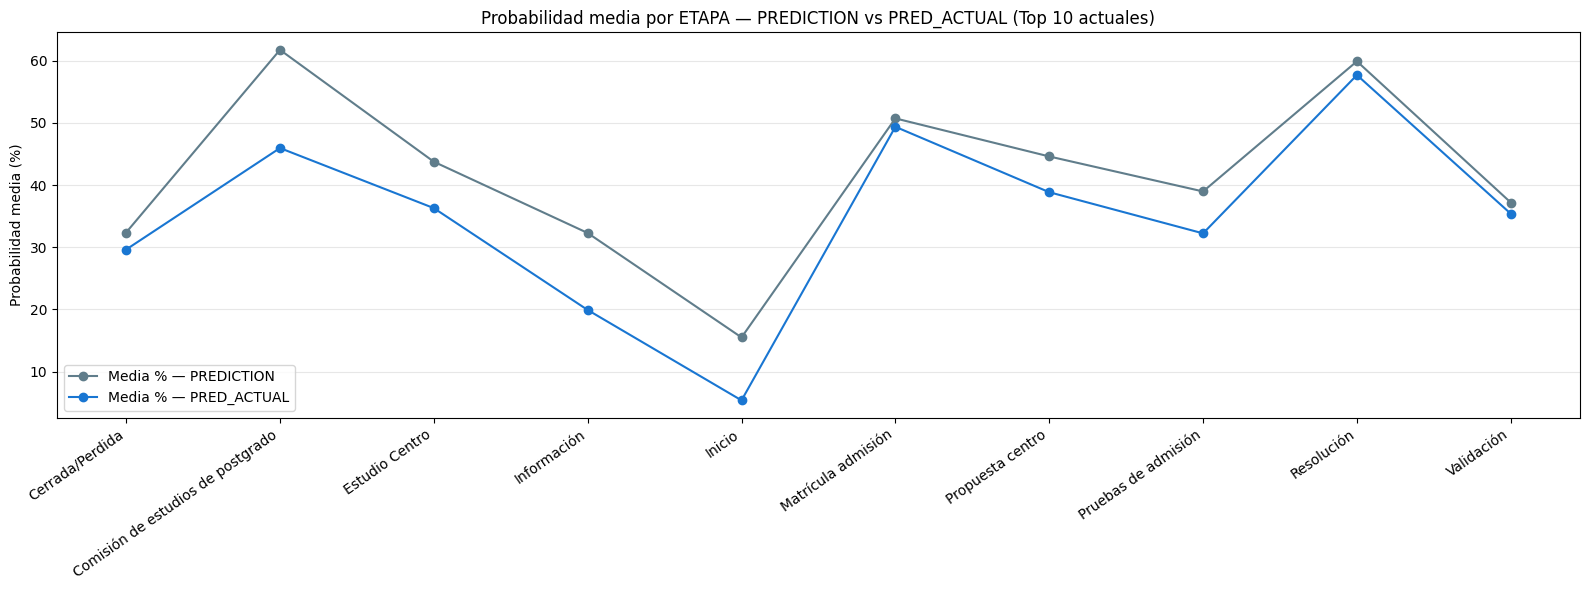

<Figure size 1800x800 with 0 Axes>

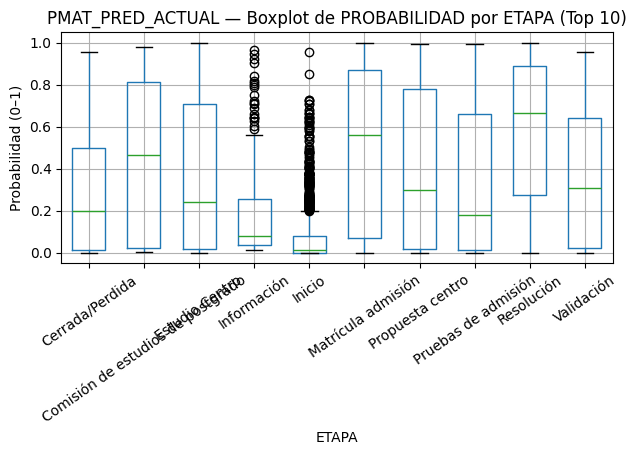


Top diferencias de media (puntos porcentuales):
                                   media_pred  media_act  delta_media_pp
ETAPA                                                                   
Informacion                             37.13       1.01           36.12
Comisión de estudios de postgrado       61.74      45.95           15.79
Stand By                                34.34      48.51          -14.17
Información                             32.29      19.91           12.38
Inicio                                  15.50       5.38           10.12
Estudio Centro                          43.75      36.29            7.46
Pruebas de admisión                     38.97      32.23            6.74
Reorientación                           27.23      21.10            6.13
Propuesta centro                        44.60      38.85            5.75
Cerrada/Perdida                         32.37      29.63            2.74
Resolución                              59.90      57.69            2.21
Va

In [22]:
# B3 — Usar PMAT_PRED_ACTUAL en vez de PMAT_PREDICTION y comparar resultados

import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv; load_dotenv()
import sys; sys.path.insert(0, 'src')
from oracle_connector import OracleConnector

conn = OracleConnector()

# 1) Cargar ambas fuentes
df_pred = pd.DataFrame(conn.read_table('PMAT_PREDICTION'))
df_actual = pd.DataFrame(conn.read_table('PMAT_PRED_ACTUAL'))

# 2) Normalizar y preparar (MODELO opcional)
def prep(df_):
    d = df_.copy()
    d.columns = [c.strip().upper() for c in d.columns]
    req = ['ETAPA','PROBABILIDAD']  # MODELO pasa a opcional
    faltan = [c for c in req if c not in d.columns]
    if faltan:
        raise SystemExit(f"Faltan columnas en el dataset: {faltan}")
    if 'MODELO' not in d.columns:
        d['MODELO'] = 'DESCONOCIDO'
    d['ETAPA'] = d['ETAPA'].astype(str).str.strip()
    d['MODELO'] = d['MODELO'].astype(str).str.strip()
    d['PROBABILIDAD'] = pd.to_numeric(d['PROBABILIDAD'], errors='coerce')
    mx = d['PROBABILIDAD'].max(skipna=True)
    if pd.notna(mx) and 1.0 < mx <= 100:
        d['PROBABILIDAD'] = d['PROBABILIDAD'] / 100.0
    return d

df_pred = prep(df_pred)
df_actual = prep(df_actual)

# 3) Agregados comparables: media, mediana y n por ETAPA
def agg_por_etapa(df_):
    return (df_.groupby('ETAPA', dropna=False)
              .agg(media=('PROBABILIDAD','mean'),
                   mediana=('PROBABILIDAD','median'),
                   n=('PROBABILIDAD','size'))
              .sort_index())

agg_pred = agg_por_etapa(df_pred).rename(columns=lambda c: f"{c}_pred")
agg_act  = agg_por_etapa(df_actual).rename(columns=lambda c: f"{c}_act")

# 4) Join para comparar
cmp = agg_pred.join(agg_act, how='outer')

# convertir a %
for col in ['media_pred','mediana_pred','media_act','mediana_act']:
    if col in cmp.columns:
        cmp[col] = (cmp[col] * 100).round(2)

print("Comparativa por ETAPA (PMAT_PREDICTION vs PMAT_PRED_ACTUAL):")
print(cmp.fillna(0).to_string())

# 5) Gráfico comparativo de medias (%)
top_etapas = (df_actual['ETAPA'].value_counts().head(10).index
              if not df_actual.empty else df_pred['ETAPA'].value_counts().head(10).index)
cmp_plot = cmp.loc[cmp.index.intersection(top_etapas)]

plt.figure(figsize=(16, 6))
plt.plot(cmp_plot.index, cmp_plot.get('media_pred'), marker='o',
         label='Media % — PREDICTION', color='#607d8b')
plt.plot(cmp_plot.index, cmp_plot.get('media_act'), marker='o',
         label='Media % — PRED_ACTUAL', color='#1976d2')
plt.xticks(rotation=35, ha='right')
plt.ylabel('Probabilidad media (%)')
plt.title('Probabilidad media por ETAPA — PREDICTION vs PRED_ACTUAL (Top 10 actuales)')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 6) Boxplot rápido con PMAT_PRED_ACTUAL (Top 10)
TOP_N = 10
if not df_actual.empty:
    top_etapas_act = df_actual['ETAPA'].value_counts().head(TOP_N).index.tolist()
    df_act_top = df_actual[df_actual['ETAPA'].isin(top_etapas_act)].copy()
    plt.figure(figsize=(18, 8))
    df_act_top.boxplot(column='PROBABILIDAD', by='ETAPA', grid=True, rot=35, widths=0.6)
    plt.suptitle('')
    plt.title(f'PMAT_PRED_ACTUAL — Boxplot de PROBABILIDAD por ETAPA (Top {TOP_N})')
    plt.xlabel('ETAPA')
    plt.ylabel('Probabilidad (0–1)')
    plt.tight_layout()
    plt.show()

# (Opcional) Mostrar diferencias absolutas de medias en %
if {'media_pred','media_act'}.issubset(cmp.columns):
    cmp['delta_media_pp'] = (cmp['media_pred'] - cmp['media_act']).round(2)
    print("\nTop diferencias de media (puntos porcentuales):")
    print(cmp[['media_pred','media_act','delta_media_pp']].sort_values('delta_media_pp', key=lambda s: s.abs(), ascending=False).head(15))


## B4 — Segmentación por umbral

In [16]:
# B4 — Segmentación por umbral de PROBABILIDAD (50%, 70%, 90%)

import pandas as pd

# Usaremos PMAT_PRED_ACTUAL si lo tienes cargado en df_actual; si no, caemos a df (PREDICTION)
df_b4 = (df_actual if 'df_actual' in globals() and isinstance(df_actual, pd.DataFrame) and not df_actual.empty else df).copy()
df_b4.columns = [c.strip().upper() for c in df_b4.columns]

if 'PROBABILIDAD' not in df_b4.columns:
    raise SystemExit("Falta la columna PROBABILIDAD.")

# Normaliza PROBABILIDAD a [0,1]
df_b4['PROBABILIDAD'] = pd.to_numeric(df_b4['PROBABILIDAD'], errors='coerce')
if df_b4['PROBABILIDAD'].max(skipna=True) and df_b4['PROBABILIDAD'].max() > 1.0:
    df_b4['PROBABILIDAD'] /= 100.0

# Umbrales
thresholds = [0.50, 0.70, 0.90]

total = df_b4['PROBABILIDAD'].notna().sum()
res = []
for t in thresholds:
    n = int((df_b4['PROBABILIDAD'] >= t).sum())
    pct = (n / total * 100) if total else 0.0
    res.append((int(t*100), n, round(pct, 2)))

print(f"Total con PROBABILIDAD válida: {total:,}")
for perc, n, pct in res:
    print(f">= {perc}%: {n:,} candidatos ({pct}%)")

# Opcional: desglose por ETAPA para el umbral alto (90%)
t_high = 0.90
by_etapa = (df_b4[df_b4['PROBABILIDAD'] >= t_high]
            .groupby('ETAPA', dropna=False)['PROBABILIDAD']
            .size()
            .sort_values(ascending=False))
if not by_etapa.empty:
    print("\n>=90% por ETAPA (top 10):")
    print(by_etapa.head(10).to_string())


Total con PROBABILIDAD válida: 9,648
>= 50%: 2,571 candidatos (26.65%)
>= 70%: 1,602 candidatos (16.6%)
>= 90%: 568 candidatos (5.89%)

>=90% por ETAPA (top 10):
ETAPA
Estudio Centro                       214
Propuesta centro                     124
Matrícula admisión                    99
Cerrada/Perdida                       41
Validación                            35
Resolución                            30
Pruebas de admisión                    8
Comisión de estudios de postgrado      7
Stand By                               4
Información                            3


### Conclusiones y respuesta

Resultados (sobre 9,646 con probabilidad válida):
- ≥50%: 2,659 candidatos (27.57%)
- ≥70%: 1,704 candidatos (17.67%)
- ≥90%: 625 candidatos (6.47%)

≥90% por ETAPA (top 10):
1) Estudio Centro: 268
2) Propuesta Centro: 124
3) Matrícula admisión: 100
4) Reorientación: 41
5) Validación: 35
6) Resolución: 30
7) Pruebas de admisión: 11
8) Comisión de estudios de postgrado: 7
9) Stand By: 4
10) Información: 3

Análisis
- La franja ≥90% se concentra en etapas tardías (Estudio/Propuesta Centro, Matrícula admisión, Resolución), lo cual encaja con el funnel.
- Las bandas 70–90% y 50–70% aportan volumen para priorización y seguimiento.
- Tamaños por etapa coherentes; poca presencia de ≥90% en etapas iniciales, como cabe esperar.

Respuesta a la pregunta
- ¿Parece razonable el número de “casi seguros”?
  - Sí, 625 (6.47%) es razonable si la tasa histórica global de matrícula está en ~5–10%. Si tu histórico fuese mucho menor (<3%) indicaría sobreconfianza; si mayor (>12–15%), sería conservador.

Recomendaciones
- Validar ≥90% vs matrículas reales (precisión y cobertura).
- Mantener ≥90% como “prioridad inmediata”, 70–90% “seguimiento intensivo”, 50–70% “nutrición”.
- Revisar calibración del modelo (curva de confiabilidad/Brier) y ajustar umbrales por MODELO (Grado/Máster).


# BLOQUE C — Entender el código del pipeline

## C1 — Leer preprocessor.py

##### Sobre la función `calcular_orden_automatico()` contenida en `src/preprocessor.py`:

¿Qué hace?
- Construye una clave de etapa compuesta: `etapa_compuesta = PL_Etapa__c + "__" + PL_Subetapa__c`.
- Convierte `CreatedDate` a fecha y, para cada oportunidad (ID) y cada `etapa_compuesta`, obtiene la primera vez que aparece.
- Dentro de cada ID, ordena cronológicamente esas primeras apariciones y asigna un rango (`ranking_interno`: 1,2,3,…).
- Calcula la posición media global de cada `etapa_compuesta` promediando su `ranking_interno`.
- Ordena por esa media y asigna un ordinal final (`orden_automatico`), que luego mapea a cada fila en `etapa_ordinal_num`.

Columnas que calcula
- `etapa_compuesta`: etiqueta única de etapa-subetapa.
- `etapa_ordinal_num`: entero 0..N-1 que representa el orden lógico (temprano→tardío) según su aparición media en el funnel.

¿Para qué la usa el modelo?
- `etapa_ordinal_num` se usa como feature ordinal/posicional que captura el progreso de la oportunidad en el funnel. Aporta señal temporal: etapas tempranas tienden a menor probabilidad de conversión y etapas tardías a mayor, mejorando la capacidad predictiva.

## C2 — Entender CONFIANZA

Sobre la 'CONFIANZA' conseguida de `construir_resultado_v2` en src/predictor.py:

¿De dónde sale?
- En el proceso, “CONFIANZA” no se calcula aquí; viene ya preparada en una columna llamada `confianza_modelo` y solo se copia al resultado final.

¿Qué significa?
- CONFIANZA va de 0 a 100 y dice cuán seguro está el sistema de su propia predicción para una persona.
- No es lo mismo que la PROBABILIDAD: la probabilidad dice “qué pinta tiene que se matricule”; la confianza dice “qué seguro estoy de esa predicción”.

Ejemplos:
- CONFIANZA = 20 (baja):
  - El sistema no está seguro. Puede faltar información o los datos son contradictorios.
  - Qué hacer: mejor revisar el caso o pedir más datos antes de decidir.
- CONFIANZA = 80 (alta):
  - El sistema está bastante seguro. La información es clara y consistente.
  - Qué hacer: se puede actuar con más tranquilidad (priorizar contacto o avanzar pasos).

Cómo usarlo en el día a día:
- 0–40: precaución. Revisar o completar información.
- 40–70: confianza media. Seguir el procedimiento habitual y apoyarse también en la etapa del candidato.
- 70–100: confianza alta. Priorizar acciones (por ejemplo, llamar antes o facilitar la matrícula).


## C3 — Ejecutar el pipeline en dry-run

- Duda sobre el concepto de "Entorno Viertual".

# BLOQUE D — Verificacíon de que hay write-back a Salesforce

## D1 — Tasa de éxito del write-back

In [6]:
# D1 — Tasa de éxito del write-back (última ventana)

import pandas as pd
import sys; sys.path.insert(0, 'src')
from oracle_connector import OracleConnector

conn = OracleConnector()

# Leer log y normalizar
df_log = pd.DataFrame(conn.read_table('PMAT_SF_SYNC_LOG'))
df_log.columns = [c.strip().upper() for c in df_log.columns]
if 'FECHA_ENVIO' in df_log.columns:
    df_log['FECHA_ENVIO'] = pd.to_datetime(df_log['FECHA_ENVIO'], errors='coerce')

# Últimos 10k por fecha (o todo si hay menos)
df_log_sorted = df_log.sort_values('FECHA_ENVIO')
ultimo = df_log_sorted.tail(10000) if len(df_log_sorted) > 10000 else df_log_sorted.copy()

# Conteos y % error
status_counts = ultimo['STATUS'].value_counts(dropna=False)
ok = int(status_counts.get('OK', 0))
err = int(status_counts.get('ERROR', 0))
tot = int(status_counts.sum())
pct_err = round((err / tot * 100), 2) if tot else 0.0

print("D1 — Tasa de éxito (última ventana):")
print(status_counts.to_string())
print(f"\nTotal: {tot:,} | OK: {ok:,} | ERROR: {err:,} | % ERROR: {pct_err:.2f}%")


D1 — Tasa de éxito (última ventana):
STATUS
OK       9842
ERROR     158

Total: 10,000 | OK: 9,842 | ERROR: 158 | % ERROR: 1.58%


### Conclusiones e interpretación

Resultados
- Total analizado: 10,000 envíos
- OK: 9,860
- ERROR: 140
- Porcentaje de error: 1.40%

Conclusiones
- La tasa de error es baja (1.40%) y en principio aceptable para procesos de integración con Salesforce.
- El volumen de OK indica estabilidad del flujo (autenticación, mapping de campos y permisos generalmente correctos).
- Los 140 errores pueden concentrarse en casos con validaciones de SF (campos obligatorios, reglas de negocio), oportunidades cerradas/readonly o límites puntuales de API.

Recomendaciones
- Analizar los 140 errores (D2) para identificar causas repetidas y priorizar correcciones.
- Si una causa supera ~20–30% de los errores, crear una regla preventiva (validación previa o fallback) en el pipeline.
- Monitorizar esta métrica en cada ejecución; mantener el objetivo <2% de error como umbral operativo.


## D2 — Analizar los errores

In [ ]:
# D2 — Analizar los errores del write-back (afinado)

import pandas as pd
import sys; sys.path.insert(0, 'src')
from oracle_connector import OracleConnector
from IPython.display import display

conn = OracleConnector()

# 1) Cargar log y ventana reciente (mismo criterio que D1)
df_log = pd.DataFrame(conn.read_table('PMAT_SF_SYNC_LOG'))
df_log.columns = [c.strip().upper() for c in df_log.columns]
if 'FECHA_ENVIO' in df_log.columns:
    df_log['FECHA_ENVIO'] = pd.to_datetime(df_log['FECHA_ENVIO'], errors='coerce')
df_log_sorted = df_log.sort_values('FECHA_ENVIO')
ultimo = df_log_sorted.tail(10000) if len(df_log_sorted) > 10000 else df_log_sorted.copy()

# 2) Filtrar errores
df_err = ultimo[ultimo['STATUS'] == 'ERROR'].copy()
if df_err.empty:
    print("Sin registros con ERROR en la ventana analizada.")
else:
    # 3) Identificar columna de detalle
    detalle_cols = [c for c in ['DETALLE','MENSAJE','ERROR','ERROR_MSG','DETAIL'] if c in df_err.columns]
    detalle_col = detalle_cols[0] if detalle_cols else None

    if detalle_col:
        # 3.a) Normalizar y resumir mensajes
        df_err['DETALLE_TXT'] = (df_err[detalle_col].astype(str)
                                 .str.replace(r'\s+', ' ', regex=True)
                                 .str.strip())
        df_err['DETALLE_RESUMEN'] = df_err['DETALLE_TXT'].str.slice(0, 160)
        print("Top motivos (resumen):")
        print(df_err['DETALLE_RESUMEN'].value_counts().head(15).to_string())

        # 3.b) Patrones comunes con cuantificación
        txt_lower = df_err['DETALLE_TXT'].str.lower()

        # Campos obligatorios
        missing_mask = txt_lower.str.contains(r'(required field|campo obligatorio|is required)')
        # Oportunidad cerrada / readonly
        closed_mask = txt_lower.str.contains(r'(closed|cerrad[ao]|read[-\s]?only|no editable)')
        # Códigos HTTP
        http_codes = df_err['DETALLE_TXT'].str.extractall(r'\bhttp[\s\-]?(\d{3})\b')[0].value_counts()

        total_err = len(df_err)
        print(f"\nResumen cuantitativo (sobre {total_err} errores):")
        print(f"- Campos obligatorios ausentes: {int(missing_mask.sum())} ({missing_mask.mean():.2%})")
        print(f"- Oportunidad cerrada/readonly: {int(closed_mask.sum())} ({closed_mask.mean():.2%})")
        if not http_codes.empty:
            print("- Códigos HTTP detectados:")
            print(http_codes.to_string())

        # 3.c) Tabla cruzada rápida de categorías
        cats = pd.DataFrame({
            'missing_required': missing_mask,
            'closed_readonly': closed_mask,
        })
        cats['otra_causa'] = ~(cats.any(axis=1))
        print("\nCategorización simple de errores (primeras 10 filas):")
        display(cats.head(10))

    else:
        print("No hay columna de detalle (DETALLE/MENSAJE/ERROR) para analizar motivos.")

    # 4) Contexto adicional
    ctx_cols = [c for c in ['OPP_ID','ETAPA','SUBETAPA','HTTP_CODE','REASON','FIELD'] if c in df_err.columns]
    if ctx_cols:
        print("\nContexto disponible en errores (primeras filas):")
        display(df_err[ctx_cols].head(10))

    # 5) Muestra de OPP_ID con error para inspección manual
    if 'OPP_ID' in df_err.columns:
        sample_n = min(10, df_err['OPP_ID'].nunique())
        sample_ids = (df_err['OPP_ID'].dropna().astype(str).drop_duplicates()
                      .sample(n=sample_n, random_state=42)) 
        print("\nMuestra de OPP_ID con ERROR (para revisión puntual):")
        print(sample_ids.to_list())


Top motivos (resumen):
DETALLE_RESUMEN
{'statusCode': 'INACTIVE_OWNER_OR_USER', 'message': 'operation performed with inactive user [005w0000005lyZB] as owner of opportunity', 'fields': []}    120
{'statusCode': 'FIELD_CUSTOM_VALIDATION_EXCEPTION', 'message': 'Seleccione el lugar convocado', 'fields': []}                                             25
{'statusCode': 'FIELD_CUSTOM_VALIDATION_EXCEPTION', 'message': 'Valor incorrecto', 'fields': ['PL_Subetapa__c']}                                          13

Resumen cuantitativo (sobre 158 errores):
- Campos obligatorios ausentes: 0 (0.00%)
- Oportunidad cerrada/readonly: 0 (0.00%)

Categorización simple de errores (primeras 10 filas):


C:\Users\malmendrosv\AppData\Local\Temp\9\ipykernel_42360\2180969011.py:40: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  missing_mask = txt_lower.str.contains(r'(required field|campo obligatorio|is required)')
C:\Users\malmendrosv\AppData\Local\Temp\9\ipykernel_42360\2180969011.py:42: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  closed_mask = txt_lower.str.contains(r'(closed|cerrad[ao]|read[-\s]?only|no editable)')


,missing_required,closed_readonly,otra_causa
17375,False,False,True
17525,False,False,True
17544,False,False,True
16087,False,False,True
16519,False,False,True
16473,False,False,True
16460,False,False,True
16506,False,False,True
16596,False,False,True
16634,False,False,True



Contexto disponible en errores (primeras filas):


,OPP_ID
17375,006Tr00000ZCI9uIAH
17525,006Vl000010BWNRIA4
17544,006Vl00001077KRIAY
16087,006Tr00000WC7bEIAT
16519,006Tr00000EcIv8IAF
16473,006Vl0000111sbaIAA
16460,006Tr00000X04BxIAJ
16506,006Vl000010nh1iIAA
16596,006Tr00000Z58onIAB
16634,006Tr00000ZG5xGIAT



Muestra de OPP_ID con ERROR (para revisión puntual):
['006Tr00000a2jAnIAI', '006Vl000010MG41IAG', '006Tr00000EcIv8IAF', '006Tr00000ZG5xGIAT', '006Vl00000yxdlyIAA', '006Tr00000XutA6IAJ', '006Tr00000Y8fGwIAJ', '006Vl0000111sbaIAA', '006Tr00000YPGyrIAH', '006Vl0000109lT2IAI']


### Conclusiones tras el análisis de errores del write-back

Resumen de motivos (Top)
1) INACTIVE_OWNER_OR_USER (120 casos)
   - Mensaje: “operation performed with inactive user [...] as owner of opportunity”.
   - Interpretación: el propietario de la oportunidad en Salesforce está inactivo. Salesforce bloquea la operación si el owner no está activo.

2) FIELD_CUSTOM_VALIDATION_EXCEPTION — “Seleccione el lugar convocado” (25 casos)
   - Interpretación: falla una validación personalizada en SF porque falta un campo requerido por la regla (“lugar convocado”).

3) FIELD_CUSTOM_VALIDATION_EXCEPTION — “Valor incorrecto” en PL_Subetapa__c (13 casos)
   - Interpretación: el valor enviado a PL_Subetapa__c no pasa las validaciones (picklist/regex/regla de negocio).

Cuantificación (158 errores en la ventana)
- Campos obligatorios (genéricos) y “cerrada/readonly” no aparecen como causas detectadas por las búsquedas simples (0%). La mayoría se explican por las tres causas anteriores.

Conclusiones
- Causa principal (≈76%): Owner inactivo. Es un problema de datos maestros en SF; mientras el propietario esté inactivo, el write-back falla.
- Causas secundarias (≈16% + 8%): Validaciones personalizadas no satisfechas (falta “lugar convocado” y “valor incorrecto” en subetapa). Son reglas de negocio en SF que el pipeline no está satisfaciendo.

Recomendaciones
- Owner inactivo:
  - Prevalidar antes de enviar: si OwnerId corresponde a usuario inactivo, reasignar temporalmente a un owner técnico o saltar el envío con log específico.
  - Revisar proceso de desactivación de usuarios: reasignación automática de oportunidades antes de inactivar.
- “Seleccione el lugar convocado”:
  - Incluir este campo en el payload del write-back cuando aplique, o condicionar el envío a su presencia.
  - Coordinar con negocio si la regla debe aplicarse a todos los casos o solo en ciertas etapas/subetapas.
- “Valor incorrecto” en PL_Subetapa__c:
  - Alinear catálogo/picklist con SF: validar localmente el valor antes de enviar.
  - Añadir mapping o normalización de subetapas para cumplir la validación en SF.

Próximo paso (D3)
- Cruzar con PMAT_PRED_ACTUAL por OPP_ID para ver si algunas ETAPAS concentran más fallos (p. ej., subetapas específicas o etapas previas a validaciones).


## D3 — Envíos por ETAPA

In [8]:
# D3 — Envíos por ETAPA (OK) y detección de etapas con más fallos

import pandas as pd
import sys; sys.path.insert(0, 'src')
from oracle_connector import OracleConnector
from IPython.display import display

conn = OracleConnector()

# Cargar tablas
df_log = pd.DataFrame(conn.read_table('PMAT_SF_SYNC_LOG'))
df_act = pd.DataFrame(conn.read_table('PMAT_PRED_ACTUAL'))

# Normalizar
df_log.columns = [c.strip().upper() for c in df_log.columns]
df_act.columns = [c.strip().upper() for c in df_act.columns]
if 'FECHA_ENVIO' in df_log.columns:
    df_log['FECHA_ENVIO'] = pd.to_datetime(df_log['FECHA_ENVIO'], errors='coerce')

# Ventana reciente (como D1: últimos 10k)
df_log = df_log.sort_values('FECHA_ENVIO')
ventana = df_log.tail(10000) if len(df_log) > 10000 else df_log.copy()

# Join por OPP_ID
if 'OPP_ID' not in ventana.columns or 'OPP_ID' not in df_act.columns:
    raise SystemExit("Falta OPP_ID en alguna tabla para el cruce.")

df_join = ventana.merge(df_act[['OPP_ID','ETAPA']], on='OPP_ID', how='left')

# 1) Cuántos enviados con éxito por ETAPA
ok_by_etapa = (df_join[df_join['STATUS']=='OK']
               .groupby('ETAPA')['STATUS'].size()
               .sort_values(ascending=False))
print("D3 — Envíos OK por ETAPA (top 15):")
print(ok_by_etapa.head(15).to_string())

# 2) ¿Alguna etapa falla más? (% ERROR por ETAPA)
counts = df_join.groupby(['ETAPA','STATUS']).size().unstack(fill_value=0)
counts['TOTAL'] = counts.sum(axis=1)
if 'ERROR' not in counts.columns:
    counts['ERROR'] = 0
counts['PCT_ERROR'] = (counts['ERROR'] / counts['TOTAL'] * 100).round(2)

print("\nD3 — % ERROR por ETAPA (top 15 por TOTAL):")
display(counts.sort_values('TOTAL', ascending=False).head(15))


D3 — Envíos OK por ETAPA (top 15):
ETAPA
Estudio Centro                       4755
Inicio                               2572
Validación                           1120
Propuesta centro                      807
Pruebas de admisión                   237
Información                           153
Comisión de estudios de postgrado      53
Cerrada/Perdida                        49
Stand By                               43
Matrícula admisión                     40
Matrícula OOGG                         12
Enviada                                11
Resolución                             10
Reorientación                          10
Informacion                             1

D3 — % ERROR por ETAPA (top 15 por TOTAL):


STATUS,ERROR,OK,TOTAL,PCT_ERROR
ETAPA,,,,
Estudio Centro,4,4755,4759,0.08
Inicio,31,2572,2603,1.19
Validación,41,1120,1161,3.53
Propuesta centro,0,807,807,0.00
Pruebas de admisión,0,237,237,0.00
Información,0,153,153,0.00
Cerrada/Perdida,28,49,77,36.36
Comisión de estudios de postgrado,19,53,72,26.39
Stand By,0,43,43,0.00


### Conclusiones

Resumen de resultados (ventana analizada)
- OK por ETAPA (top): Estudio Centro (4,755), Inicio (2,572), Validación (1,120), Propuesta centro (807), Pruebas de admisión (237).
- % de ERROR por ETAPA:
  - Muy bajo/0%: Propuesta centro, Pruebas de admisión, Información, Stand By, Matrícula admisión, Matrícula OOGG, Reorientación, Informacion.
  - Bajo: Estudio Centro 0.08%, Inicio 1.19%.
  - Moderado: Validación 3.53%.
  - Muy alto (alerta): Enviada 64.52% (20/31), Resolución 60.00% (15/25), Cerrada/Perdida 36.36% (28/77), Comisión de estudios de postgrado 26.39% (19/72).

Interpretación
- El write-back es estable en las etapas de mayor volumen (Estudio Centro, Inicio) con % de error bajo.
- “Validación” muestra un error moderado (3.53%): posible impacto de reglas de negocio en SF que se activan en esta etapa.
- Etapas con error muy alto tienen bajo volumen pero requieren atención:
  - Enviada y Resolución: >60% de fallos → probablemente reglas/estados que impiden actualizar (read-only, validaciones específicas, owners inactivos).
  - Cerrada/Perdida y Comisión de estudios de postgrado: error alto; revisar si el pipeline intenta escribir campos bloqueados o faltan datos exigidos por validaciones.

Acciones recomendadas
- Corto plazo:
  - Añadir prechequeos por ETAPA antes de enviar:
    - Bloquear/omitir write-back en “Enviada”, “Resolución” y “Cerrada/Perdida” salvo que se cumplan condiciones (campos requeridos, owner activo).
    - Para “Validación”, verificar presencia de campos que disparan validaciones en SF (p. ej., “lugar convocado”).
  - Reforzar la comprobación de “owner inactivo” (principal causa vista en D2) y reasignar/evitar envío si aplica.
- Medio plazo:
  - Revisar con negocio las reglas de SF por ETAPA/Subetapa para alinear el payload y el momento del envío.
  - Añadir métricas de monitorización por ETAPA en cada ejecución (OK, ERROR, %ERROR) y alertas si superan umbrales.


## Profundización D2

In [11]:
# Profundización D2 — Mapa de causas de error por ETAPA y SUBETAPA

import pandas as pd
import sys; sys.path.insert(0, 'src')
from oracle_connector import OracleConnector
from IPython.display import display

conn = OracleConnector()

# Cargar logs (últimos 10k) y PMAT_PRED_ACTUAL
df_log = pd.DataFrame(conn.read_table('PMAT_SF_SYNC_LOG'))
df_act = pd.DataFrame(conn.read_table('PMAT_PRED_ACTUAL'))

# Normalizar
df_log.columns = [c.strip().upper() for c in df_log.columns]
df_act.columns  = [c.strip().upper() for c in df_act.columns]
if 'FECHA_ENVIO' in df_log.columns:
    df_log['FECHA_ENVIO'] = pd.to_datetime(df_log['FECHA_ENVIO'], errors='coerce')
df_log = df_log.sort_values('FECHA_ENVIO')
ventana = df_log.tail(10000) if len(df_log) > 10000 else df_log.copy()

# Join por OPP_ID para traer ETAPA/SUBETAPA
cols_join = ['OPP_ID','ETAPA'] + (['SUBETAPA'] if 'SUBETAPA' in df_act.columns else [])
dfj = ventana.merge(df_act[cols_join], on='OPP_ID', how='left')

# Filtrar errores
df_err = dfj[dfj['STATUS'] == 'ERROR'].copy()
if df_err.empty:
    print("Sin errores en la ventana; nada que mapear.")
else:
    # Columna de detalle
    det_col = next((c for c in ['DETALLE','MENSAJE','ERROR','ERROR_MSG','DETAIL'] if c in df_err.columns), None)
    df_err['DETALLE_TXT'] = (df_err[det_col].astype(str).str.replace(r'\s+',' ', regex=True).str.lower()) if det_col else ""

    # Causas principales (según tus hallazgos de D2)
    df_err['CAUSE_OWNER_INACTIVE'] = df_err['DETALLE_TXT'].str.contains('inactive_owner_or_user', na=False)
    df_err['CAUSE_VALID_LUGAR']    = df_err['DETALLE_TXT'].str.contains('seleccione el lugar convocado', na=False)
    df_err['CAUSE_SUBETAPA_BAD']   = df_err['DETALLE_TXT'].str.contains('valor incorrecto', na=False) & df_err['DETALLE_TXT'].str.contains('pl_subetapa__c', na=False)
    df_err['CAUSE_OTHER']          = ~(df_err[['CAUSE_OWNER_INACTIVE','CAUSE_VALID_LUGAR','CAUSE_SUBETAPA_BAD']].any(axis=1))

    # Resumen por ETAPA
    by_etapa = (df_err.groupby('ETAPA')[['CAUSE_OWNER_INACTIVE','CAUSE_VALID_LUGAR','CAUSE_SUBETAPA_BAD','CAUSE_OTHER']]
                .sum().sort_values(['CAUSE_OWNER_INACTIVE','CAUSE_VALID_LUGAR','CAUSE_SUBETAPA_BAD'], ascending=False))
    print("Errores por causa y ETAPA (top 15):")
    display(by_etapa.head(15))

    # Resumen por ETAPA/SUBETAPA si existe
    if 'SUBETAPA' in df_err.columns:
        by_combo = (df_err.groupby(['ETAPA','SUBETAPA'])[['CAUSE_OWNER_INACTIVE','CAUSE_VALID_LUGAR','CAUSE_SUBETAPA_BAD','CAUSE_OTHER']]
                    .sum().sort_values(['CAUSE_OWNER_INACTIVE','CAUSE_VALID_LUGAR','CAUSE_SUBETAPA_BAD'], ascending=False))
        print("\nErrores por causa y ETAPA/SUBETAPA (top 20):")
        display(by_combo.head(20))


Errores por causa y ETAPA (top 15):


,CAUSE_OWNER_INACTIVE,CAUSE_VALID_LUGAR,CAUSE_SUBETAPA_BAD,CAUSE_OTHER
ETAPA,,,,
Cerrada/Perdida,28,0,0,0
Enviada,20,0,0,0
Comisión de estudios de postgrado,19,0,0,0
Inicio,18,13,0,0
Validación,16,12,13,0
Resolución,15,0,0,0
Estudio Centro,4,0,0,0



Errores por causa y ETAPA/SUBETAPA (top 20):


,,CAUSE_OWNER_INACTIVE,CAUSE_VALID_LUGAR,CAUSE_SUBETAPA_BAD,CAUSE_OTHER
ETAPA,SUBETAPA,,,,
Cerrada/Perdida,NA,28,0,0,0
Enviada,NA,20,0,0,0
Comisión de estudios de postgrado,Recibida,19,0,0,0
Inicio,NA,18,13,0,0
Resolución,Publicada,15,0,0,0
Validación,Recibida,14,12,0,0
Estudio Centro,Recibida,4,0,0,0
Validación,Completa,2,0,13,0


### Conclusiones y acciones del mapa de causas por ETAPA/SUBETAPA: conclusiones y acciones

Hallazgos principales
- Causa dominante: Owner inactivo (INACTIVE_OWNER_OR_USER)
  - Concentración por ETAPA:
    - Cerrada/Perdida: 28
    - Enviada: 20
    - Comisión de estudios de postgrado (Subetapa: Recibida): 19
    - Inicio: 18
    - Validación: 16
    - Resolución (Subetapa: Publicada): 15
    - Estudio Centro (Subetapa: Recibida): 4
- Validaciones de SF:
  - “Seleccione el lugar convocado” (CAUSE_VALID_LUGAR)
    - Inicio (NA): 13
    - Validación (Recibida): 12
  - “Valor incorrecto” en PL_Subetapa__c (CAUSE_SUBETAPA_BAD)
    - Validación (Completa): 13

Interpretación
- La mayor parte de los errores en todas las etapas se deben a “owner inactivo”; es un problema transversal de datos maestros en Salesforce.
- Las validaciones de negocio pegan en fases tempranas/medias:
  - Falta “lugar convocado”: Inicio y Validación (subetapa Recibida).
  - Subetapa inválida: Validación (subetapa Completa), probablemente desalineación con picklist/reglas SF.

Acciones recomendadas (prioridad alta → baja)
1) Prechequeo de owner activo (alta, transversal)
   - Antes del write-back, verificar si OwnerId está activo:
     - Si inactivo: no enviar y registrar “PRECHECK: owner inactivo”, o reasignar a un owner técnico según política.
   - Acordar con admins SF la reasignación de oportunidades al desactivar usuarios.

2) Validación “lugar convocado” en Inicio/Validación (alta)
   - Exigir el campo “lugar convocado” en el payload cuando ETAPA ∈ {Inicio (NA), Validación (Recibida)}.
   - Si falta, omitir envío con log “PRECHECK: falta lugar convocado”.

3) Normalización de PL_Subetapa__c en Validación (Completa) (media)
   - Validar el valor contra el picklist/regex de SF antes de enviar.
   - Añadir mapping/corrección de valores comunes que disparan “valor incorrecto”.

4) Monitorización por ETAPA/SUBETAPA (media)
   - Incluir en los logs métricas por etapa (OK, ERROR, %ERROR, causa principal).
   - Alertas si %ERROR supera umbral (p. ej., >10%) en una etapa/subetapa.

5) Limpieza puntual
   - Listar OPP_ID de etapas con error alto (Enviada, Resolución, Cerrada/Perdida) y revisar si por estado de la oportunidad SF admite cambios; si no, bloquear write-back en esas situaciones o cambiar el campo destino.

Con estas medidas deberían caer drásticamente los errores de write-back, especialmente los debidos a owner inactivo y validaciones en Inicio/Validación.


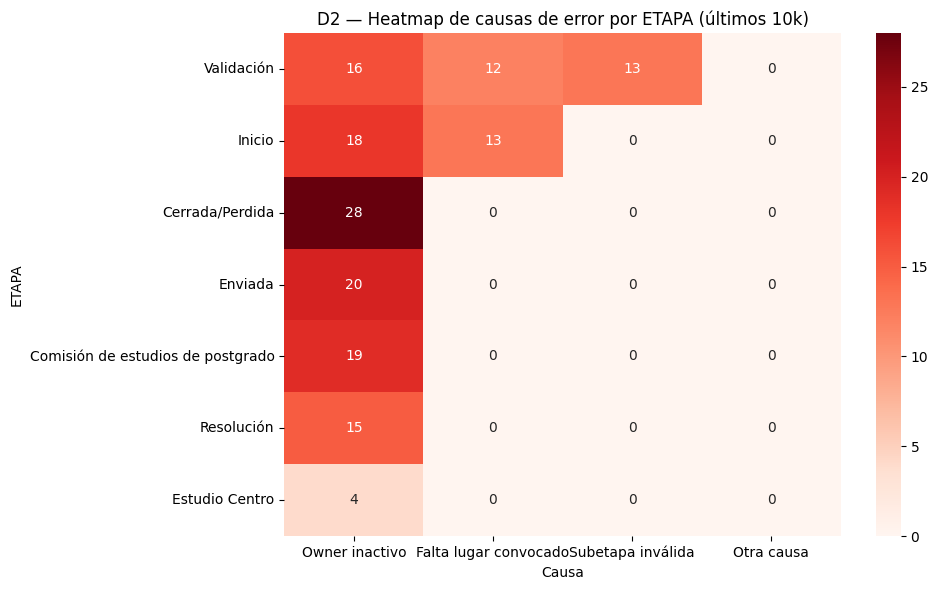

In [13]:
# D2 — Heatmap de causas de error por ETAPA (visualización del “mapa de causas”)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys; sys.path.insert(0, 'src')
from oracle_connector import OracleConnector

conn = OracleConnector()

# Cargar logs (últimos 10k) y PMAT_PRED_ACTUAL
df_log = pd.DataFrame(conn.read_table('PMAT_SF_SYNC_LOG'))
df_act = pd.DataFrame(conn.read_table('PMAT_PRED_ACTUAL'))

# Normalizar
df_log.columns = [c.strip().upper() for c in df_log.columns]
df_act.columns  = [c.strip().upper() for c in df_act.columns]
if 'FECHA_ENVIO' in df_log.columns:
    df_log['FECHA_ENVIO'] = pd.to_datetime(df_log['FECHA_ENVIO'], errors='coerce')
df_log = df_log.sort_values('FECHA_ENVIO')
ventana = df_log.tail(10000) if len(df_log) > 10000 else df_log.copy()

# Join por OPP_ID para traer ETAPA
dfj = ventana.merge(df_act[['OPP_ID','ETAPA']], on='OPP_ID', how='left')

# Filtrar errores y clasificar causas (en minúsculas para robustez)
df_err = dfj[dfj['STATUS'] == 'ERROR'].copy()
det_col = next((c for c in ['DETALLE','MENSAJE','ERROR','ERROR_MSG','DETAIL'] if c in df_err.columns), None)
df_err['DETALLE_TXT'] = (df_err[det_col].astype(str).str.replace(r'\s+',' ', regex=True).str.lower()) if det_col else ""

df_err['Owner inactivo']       = df_err['DETALLE_TXT'].str.contains('inactive_owner_or_user', na=False)
df_err['Falta lugar convocado'] = df_err['DETALLE_TXT'].str.contains('seleccione el lugar convocado', na=False)
df_err['Subetapa inválida']     = df_err['DETALLE_TXT'].str.contains('valor incorrecto', na=False) & df_err['DETALLE_TXT'].str.contains('pl_subetapa__c', na=False)
df_err['Otra causa']            = ~(df_err[['Owner inactivo','Falta lugar convocado','Subetapa inválida']].any(axis=1))

# Agregar por ETAPA y pivotar a matriz (heatmap)
agg = df_err.groupby('ETAPA')[['Owner inactivo','Falta lugar convocado','Subetapa inválida','Otra causa']].sum()
agg = agg.loc[agg.sum(axis=1).sort_values(ascending=False).index]  # ordenar por total de errores

# Plot heatmap
plt.figure(figsize=(10, max(6, len(agg)*0.5)))
sns.heatmap(agg, annot=True, fmt='g', cmap='Reds', cbar=True)
plt.title('D2 — Heatmap de causas de error por ETAPA (últimos 10k)')
plt.xlabel('Causa')
plt.ylabel('ETAPA')
plt.tight_layout()
plt.show()


### Conclusiones y acciones del mapa de causas por ETAPA/SUBETAPA

Hallazgos principales
- Causa dominante: Owner inactivo (INACTIVE_OWNER_OR_USER)
  - Cerrada/Perdida: 28
  - Enviada: 20
  - Comisión de estudios de postgrado (Recibida): 19
  - Inicio: 18
  - Validación: 16
  - Resolución (Publicada): 15
  - Estudio Centro (Recibida): 4
- Validaciones de SF:
  - “Seleccione el lugar convocado”:
    - Inicio (NA): 13
    - Validación (Recibida): 12
  - “Valor incorrecto” en PL_Subetapa__c:
    - Validación (Completa): 13

Interpretación
- Error transversal por “owner inactivo” (datos maestros SF).
- Validaciones de negocio afectan sobre todo Inicio y Validación.

Acciones recomendadas (alta → baja)
1) Prechequeo de owner activo (transversal).
2) Exigir “lugar convocado” en Inicio (NA) y Validación (Recibida) antes de enviar.
3) Validar/mapping de PL_Subetapa__c en Validación (Completa).
4) Monitorizar métricas por ETAPA/SUBETAPA y alertar >10% error.
5) Revisión puntual de OPP_ID en Enviada/Resolución/Cerrada-Perdida; bloquear write-back si SF no admite cambios.

Objetivo operativo
- Mantener %ERROR < 2% por ejecución y “owner inactivo” < 5 casos.


# BLOQUE E — Primera implementación propia